# Import Required Libraries
Import pandas, numpy, matplotlib, seaborn, and other visualization libraries needed for data analysis and graphing.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.linear_model import LinearRegression

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load and Inspect Data
Load the monet_polynomial_coefficients.csv file and display its structure, columns, and sample data.

In [20]:
# Load the data
df = pd.read_csv('monet_polynomial_coefficients.csv')

# Display basic information
print("Data shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Data shape: (323, 16)

Columns: ['filename', 'r_coeff0', 'r_coeff1', 'r_coeff2', 'r_coeff3', 'r_coeff4', 'g_coeff0', 'g_coeff1', 'g_coeff2', 'g_coeff3', 'g_coeff4', 'b_coeff0', 'b_coeff1', 'b_coeff2', 'b_coeff3', 'b_coeff4']

First few rows:


,filename,r_coeff0,r_coeff1,r_coeff2,r_coeff3,r_coeff4,g_coeff0,g_coeff1,g_coeff2,g_coeff3,g_coeff4,b_coeff0,b_coeff1,b_coeff2,b_coeff3,b_coeff4
0,View at Rouelles_ Le Havre_1858.jpg,-0.583333,7.166667,-32.916667,117.333333,-67.0,-1.458333,17.416667,-73.041667,176.083333,-88.0,-4.541667,44.916667,-138.458333,203.083333,-89.0
1,Landscape with Factories_1858_61.jpg,15.958333,-187.250000,739.041667,-1071.750000,550.0,10.958333,-132.750000,542.541667,-803.750000,431.0,5.041667,-68.750000,314.958333,-501.250000,293.0
2,Landscape with Factories_1858_61.png,1.916667,-23.333333,96.583333,-117.166667,92.0,0.333333,-6.000000,34.166667,-32.500000,43.0,2.250000,-31.000000,148.250000,-246.500000,161.0
3,Corner of a Studio_1861.jpg,18.375000,-213.416667,842.625000,-1259.583333,645.0,-4.625000,59.583333,-257.375000,460.416667,-230.0,-5.208333,64.250000,-270.791667,469.750000,-219.0
4,Still Life with Meat_1862_63.jpg,2.000000,-21.666667,71.500000,-15.833333,-15.0,0.416667,-4.333333,22.583333,-25.666667,15.0,0.541667,-3.750000,7.458333,4.750000,-1.0


# Extract Year from Painting Names
Parse the painting name column using regex or string methods to extract the year for each painting.

In [21]:
# Extract year from filename using regex
def extract_year(filename):
    match = re.search(r'(\d{4})', filename)
    return int(match.group(1)) if match else None

df['year'] = df['filename'].apply(extract_year)

# Check for any missing years
print("Missing years:", df['year'].isnull().sum())
print("Year range:", df['year'].min(), "to", df['year'].max())

# Sort by year
df = df.sort_values('year').reset_index(drop=True)
df.head()

Missing years: 0
Year range: 1858 to 1925


,filename,r_coeff0,r_coeff1,r_coeff2,r_coeff3,r_coeff4,g_coeff0,g_coeff1,g_coeff2,g_coeff3,g_coeff4,b_coeff0,b_coeff1,b_coeff2,b_coeff3,b_coeff4,year
0,View at Rouelles_ Le Havre_1858.jpg,-0.583333,7.166667,-32.916667,117.333333,-67.0,-1.458333,17.416667,-73.041667,176.083333,-88.0,-4.541667,44.916667,-138.458333,203.083333,-89.0,1858
1,Landscape with Factories_1858_61.jpg,15.958333,-187.250000,739.041667,-1071.750000,550.0,10.958333,-132.750000,542.541667,-803.750000,431.0,5.041667,-68.750000,314.958333,-501.250000,293.0,1858
2,Landscape with Factories_1858_61.png,1.916667,-23.333333,96.583333,-117.166667,92.0,0.333333,-6.000000,34.166667,-32.500000,43.0,2.250000,-31.000000,148.250000,-246.500000,161.0,1858
3,Corner of a Studio_1861.jpg,18.375000,-213.416667,842.625000,-1259.583333,645.0,-4.625000,59.583333,-257.375000,460.416667,-230.0,-5.208333,64.250000,-270.791667,469.750000,-219.0,1861
4,Still Life with Meat_1862_63.jpg,2.000000,-21.666667,71.500000,-15.833333,-15.0,0.416667,-4.333333,22.583333,-25.666667,15.0,0.541667,-3.750000,7.458333,4.750000,-1.0,1862


# Organize Coefficients by Year
Group the coefficients by extracted year and calculate summary statistics (mean, median, std) for each coefficient across years.

In [22]:
# Group by year and calculate statistics for coefficients
coeff_cols = [col for col in df.columns if 'coeff' in col]
yearly_stats = df.groupby('year')[coeff_cols].agg(['mean', 'median', 'std', 'count'])

print("Yearly statistics shape:", yearly_stats.shape)
yearly_stats.head()

Yearly statistics shape: (50, 60)


r_coeff0                               r_coeff1              \
           mean     median       std count        mean      median   
year                                                                 
1858   5.763889   1.916667  8.916699     3  -67.805556  -23.333333   
1861  18.375000  18.375000       NaN     1 -213.416667 -213.416667   
1862   2.000000   2.000000       NaN     1  -21.666667  -21.666667   
1864   0.571429   0.500000  1.568408     7   -6.023810   -1.000000   
1865   0.402778   0.208333  3.254360     3   -7.305556   -1.750000   

                          r_coeff2              ...    b_coeff2        \
             std count        mean      median  ...         std count   
year                                            ...                     
1858  104.560002     3  267.569444   96.583333  ...  229.339635     3   
1861         NaN     1  842.625000  842.625000  ...         NaN     1   
1862         NaN     1   71.500000   71.500000  ...         NaN     1   
1864   16.980975     7   20.642857   -6.291667  ...  122.787788     7   
1865   36.072298     3   34.930556    5.791667  ...   22.056837     3   

        b_coeff3                                  b_coeff4                     \
            mean      median         std count        mean median         std   
year                                                                            
1858 -181.555556 -246.500000  356.629635     3  121.666667  161.0  194.013745   
1861  469.750000  469.750000         NaN     1 -219.000000 -219.0         NaN   
1862    4.750000    4.750000         NaN     1   -1.000000   -1.0         NaN   
1864  -72.142857   32.000000  192.832881     7   46.857143  -11.0  106.444710   
1865  132.500000  148.666667   29.529999     3  -55.000000  -57.0    9.165151   

            
     count  
year        
1858     3  
1861     1  
1862     1  
1864     7  
1865     3  

[5 rows x 60 columns]

# Visualize Coefficient Trends Over Time
Create line plots showing how individual polynomial coefficients evolve over time, with separate subplots for each coefficient.

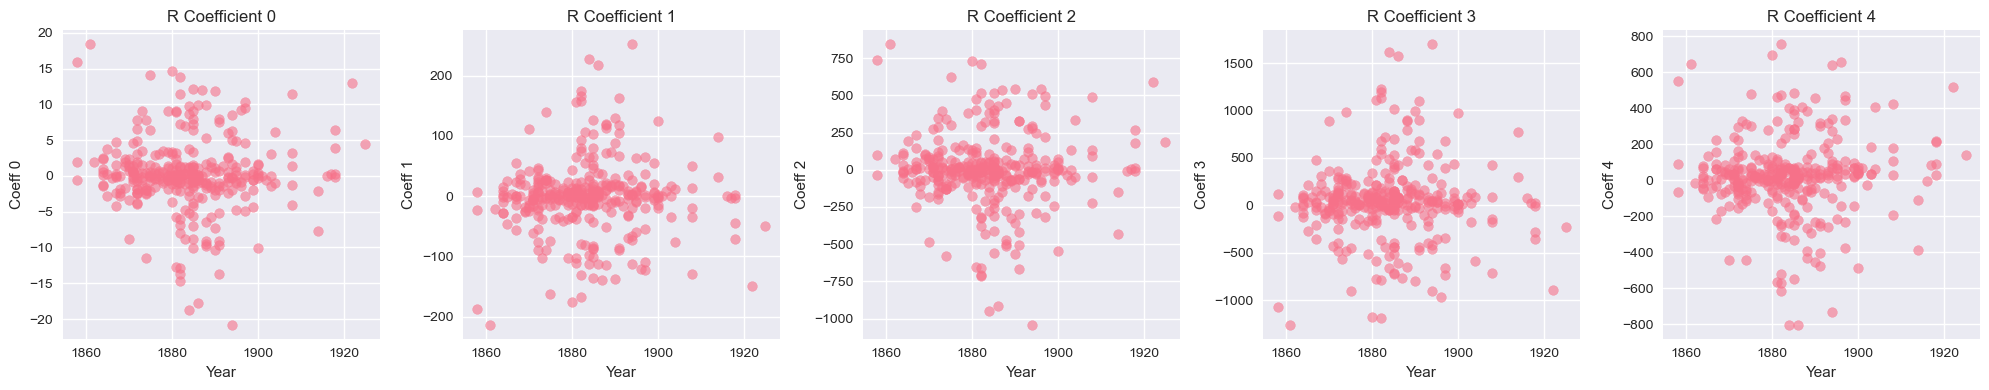

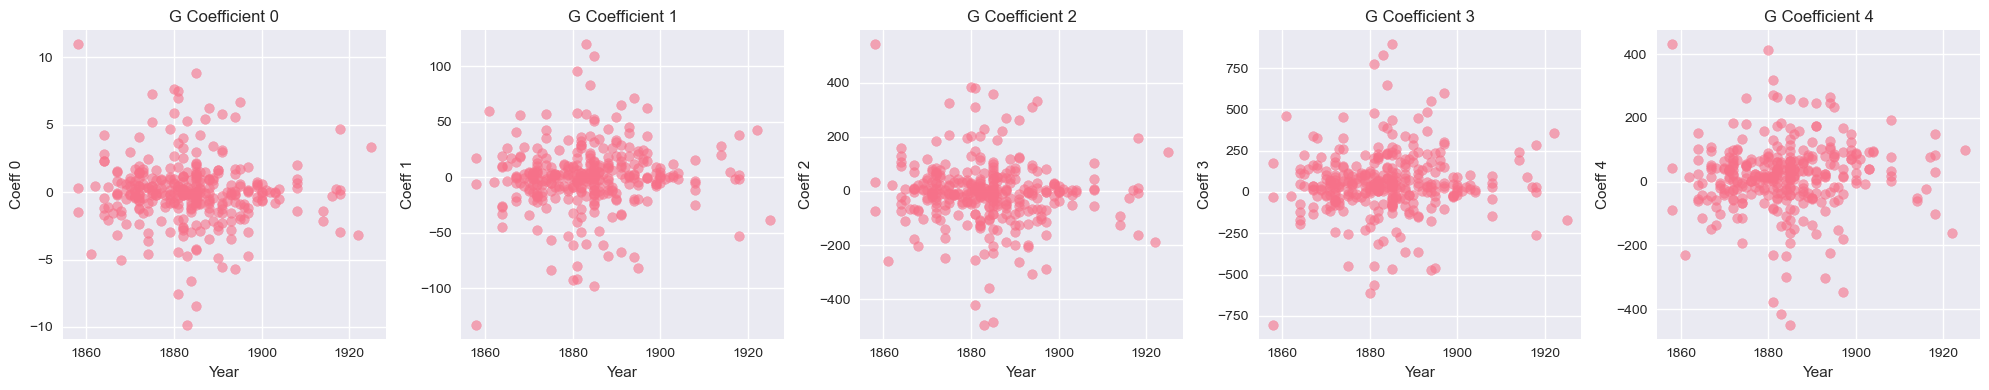

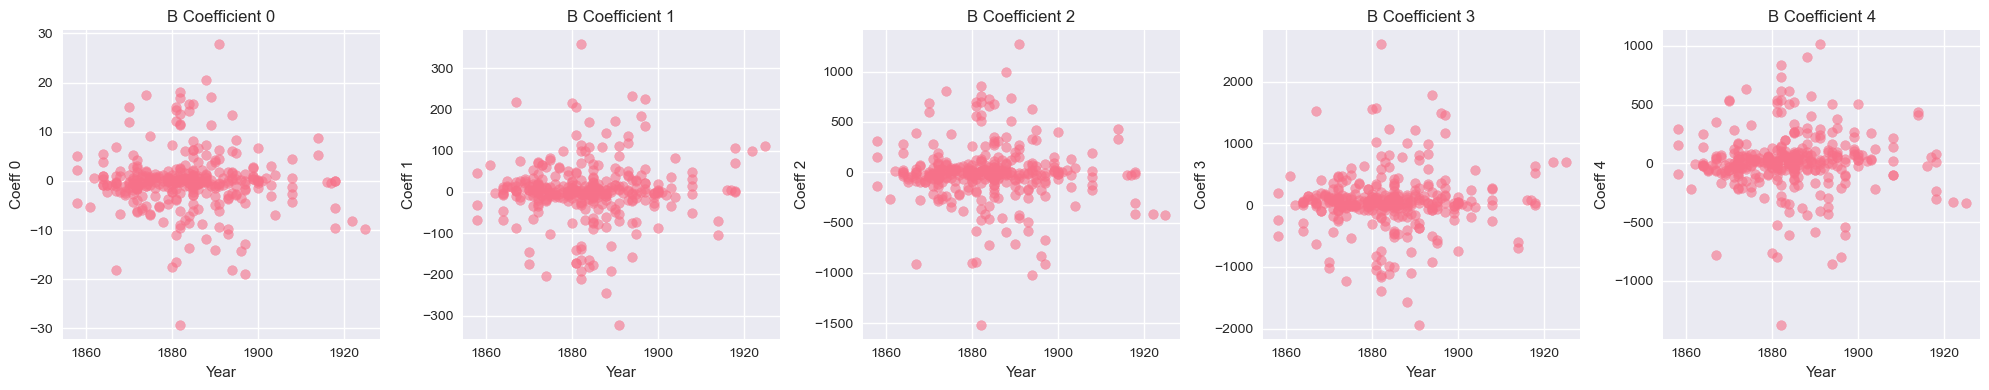

In [23]:
# Plot trends for R coefficients
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    col = f'r_coeff{i}'
    axes[i].scatter(df['year'], df[col], alpha=0.6)
    axes[i].set_title(f'R Coefficient {i}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'Coeff {i}')
plt.tight_layout()
plt.show()

# Plot trends for G coefficients
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    col = f'g_coeff{i}'
    axes[i].scatter(df['year'], df[col], alpha=0.6)
    axes[i].set_title(f'G Coefficient {i}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'Coeff {i}')
plt.tight_layout()
plt.show()

# Plot trends for B coefficients
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    col = f'b_coeff{i}'
    axes[i].scatter(df['year'], df[col], alpha=0.6)
    axes[i].set_title(f'B Coefficient {i}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(f'Coeff {i}')
plt.tight_layout()
plt.show()

# Create Multi-Panel Coefficient Comparison
Build heatmaps and scatter plots comparing multiple coefficients simultaneously, showing their relationship and changes across decades.

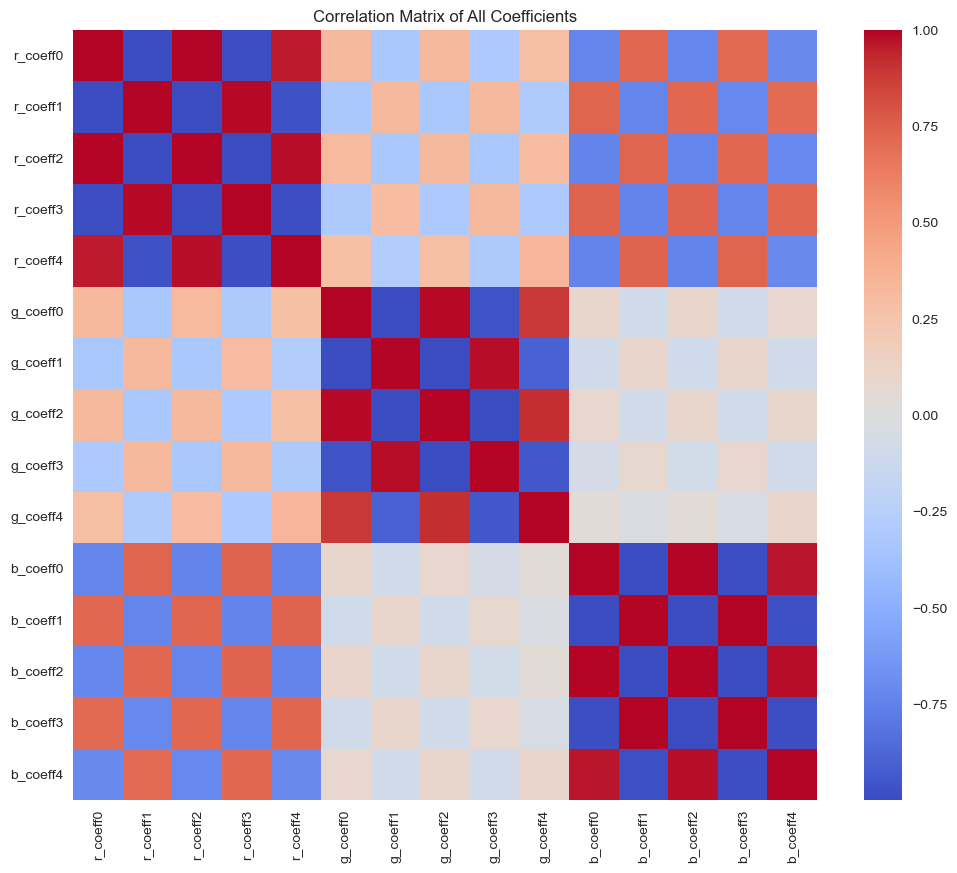

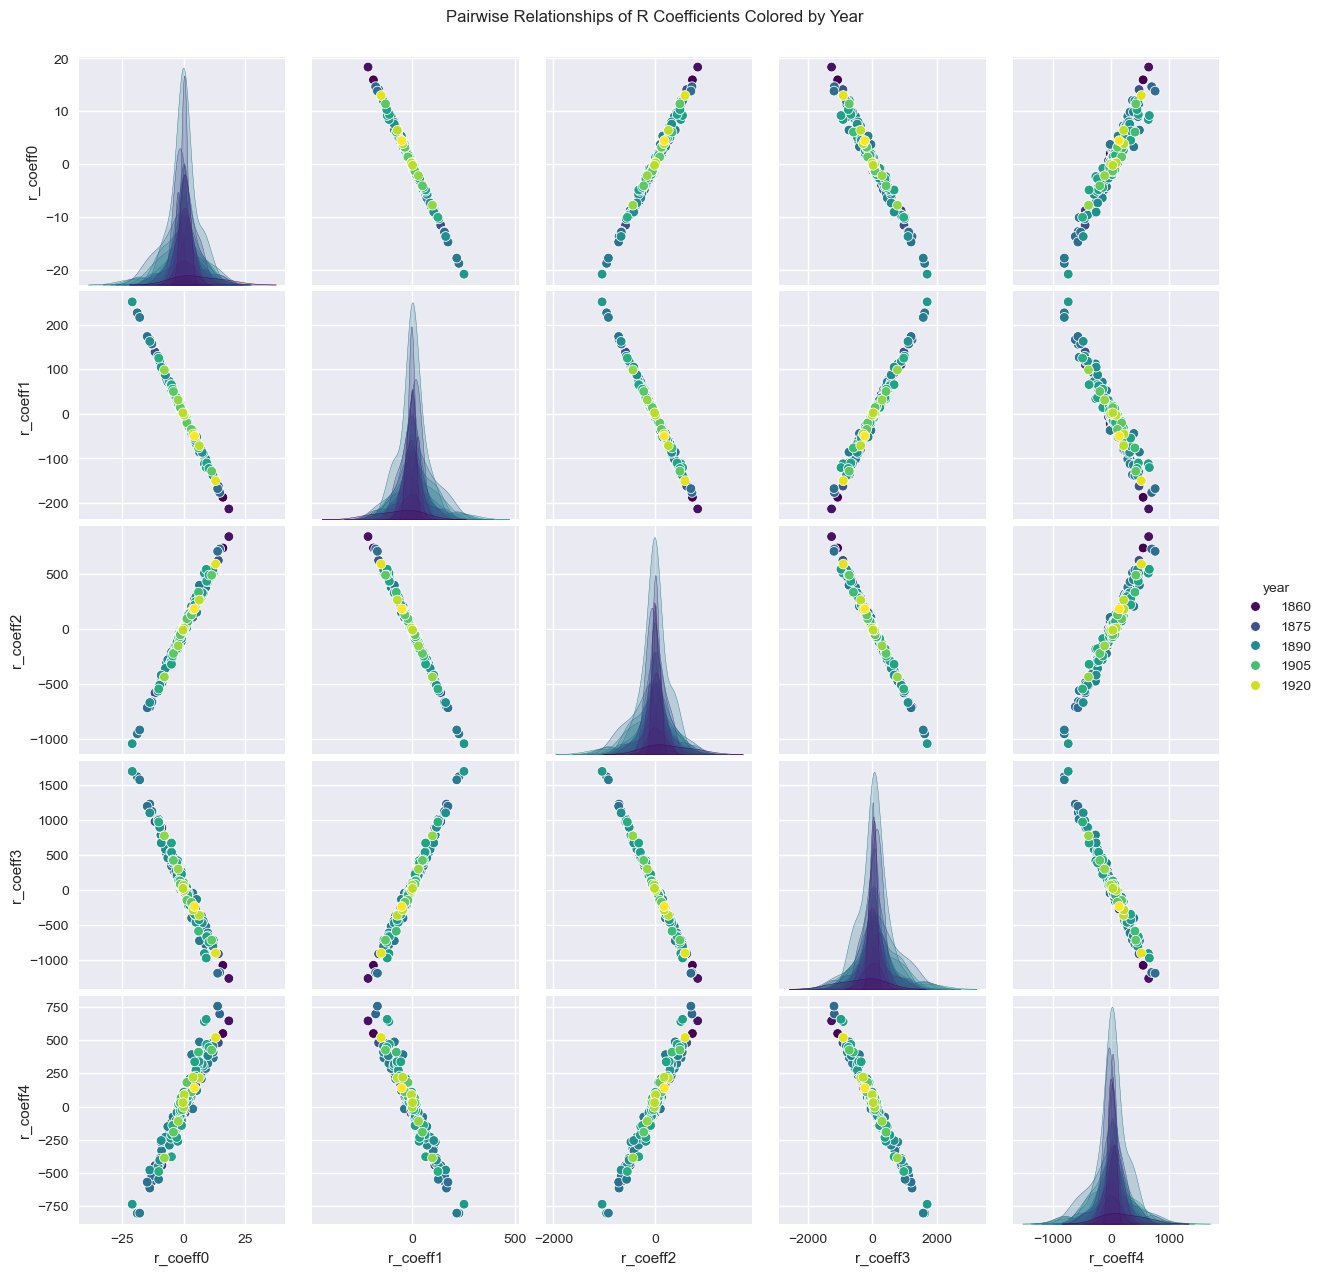

In [24]:
# Correlation heatmap of all coefficients
plt.figure(figsize=(12, 10))
corr_matrix = df[coeff_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of All Coefficients')
plt.show()

# Scatter plot matrix for R coefficients
r_cols = [f'r_coeff{i}' for i in range(5)]
sns.pairplot(df[r_cols + ['year']], hue='year', palette='viridis')
plt.suptitle('Pairwise Relationships of R Coefficients Colored by Year', y=1.02)
plt.show()

# Generate Statistical Analysis Plots
Create box plots, violin plots, and distribution plots to show the spread and variation of coefficients within different time periods.

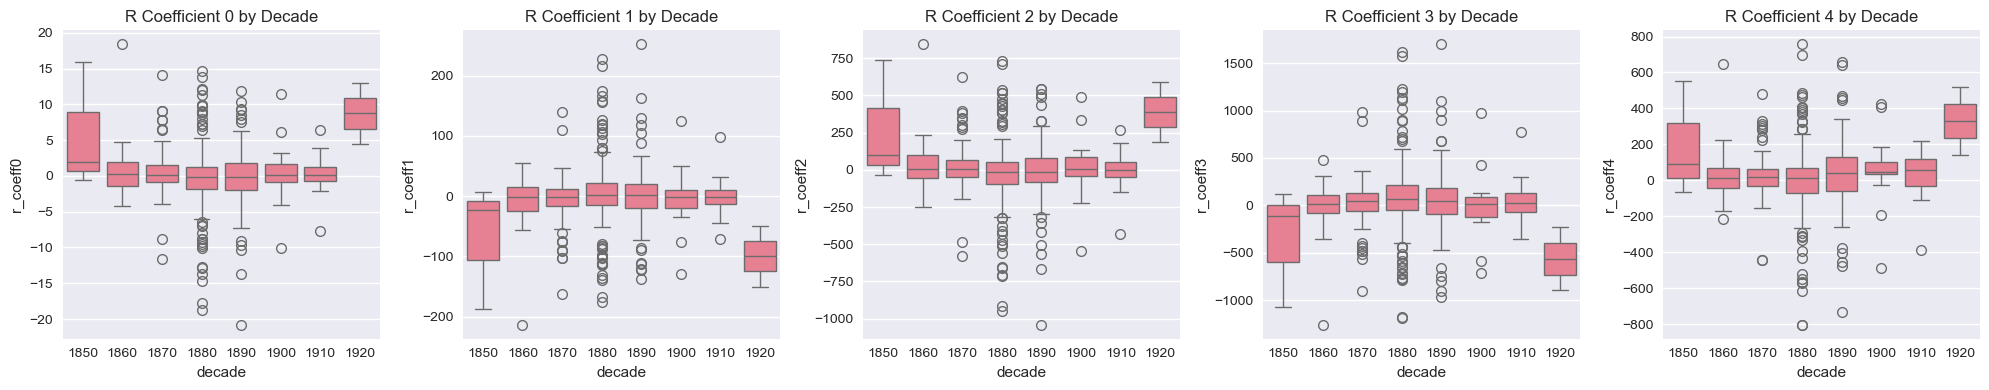

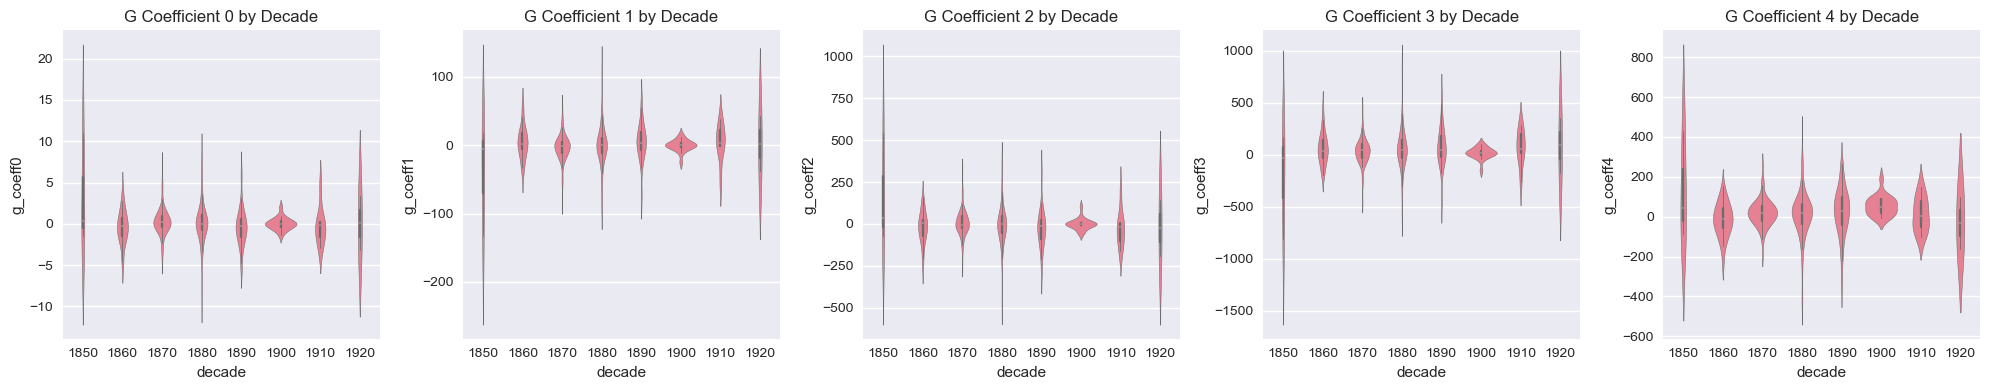

In [25]:
# Create decade categories
df['decade'] = (df['year'] // 10) * 10

# Box plot for R coefficients by decade
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    col = f'r_coeff{i}'
    sns.boxplot(data=df, x='decade', y=col, ax=axes[i])
    axes[i].set_title(f'R Coefficient {i} by Decade')
plt.tight_layout()
plt.show()

# Violin plot for G coefficients
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    col = f'g_coeff{i}'
    sns.violinplot(data=df, x='decade', y=col, ax=axes[i])
    axes[i].set_title(f'G Coefficient {i} by Decade')
plt.tight_layout()
plt.show()

# Animate Coefficient Changes Across Decades
Generate animated visualizations or temporal faceted plots showing how the coefficient space evolves across different periods of Monet's career.

In [26]:
import plotly.express as px
import plotly.graph_objects as go

# Animated scatter plot for R coefficients over time
fig = px.scatter(df, x='r_coeff0', y='r_coeff1', animation_frame='year', 
                 title='Evolution of R Coefficients Over Time',
                 labels={'r_coeff0': 'R Coeff 0', 'r_coeff1': 'R Coeff 1'})
fig.show()

# Faceted plot by decade
fig = px.scatter(df, x='year', y='r_coeff0', facet_col='decade', 
                 title='R Coefficient 0 Across Decades')
fig.show()

# Analysis of Early vs. Late Career Color Choices
Compare coefficient statistics between early (1858-1879) and late (1900-1925) periods to draw conclusions about Monet's color evolution.

Early period: 32 paintings (1858-1869)
Middle period: 283 paintings (1870-1914)
Late period: 8 paintings (1916-1925)

Mean coefficient differences (Late - Early):
r_coeff0: 2.19
r_coeff1: -24.20
r_coeff2: 91.48
r_coeff3: -153.81
r_coeff4: 112.63
g_coeff0: 0.26
g_coeff1: -1.36
g_coeff2: -2.60
g_coeff3: 4.45
g_coeff4: 20.66
b_coeff0: -3.40
b_coeff1: 41.11
b_coeff2: -173.21
b_coeff3: 278.81
b_coeff4: -120.09

Mean coefficient differences (Late - Middle):
r_coeff0: 3.56
r_coeff1: -41.30
r_coeff2: 165.15
r_coeff3: -270.86
r_coeff4: 147.36
g_coeff0: 0.18
g_coeff1: -1.35
g_coeff2: 3.56
g_coeff3: -11.33
g_coeff4: 0.61
b_coeff0: -4.28
b_coeff1: 50.29
b_coeff2: -200.75
b_coeff3: 305.82
b_coeff4: -159.54


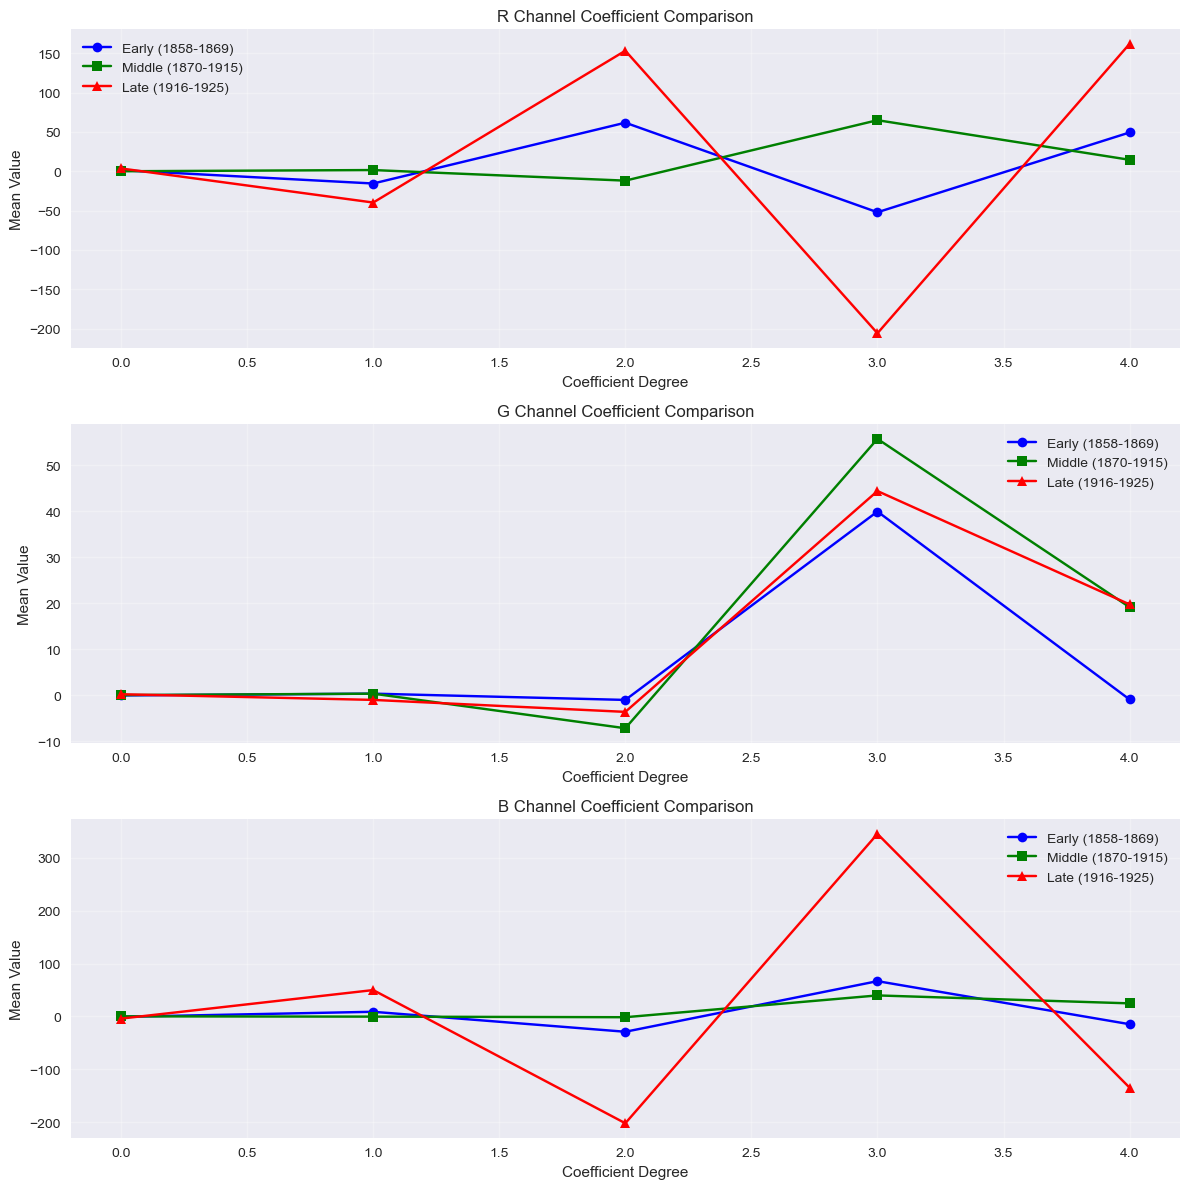


T-test results for coefficient differences:
r_coeff0 (Early vs Late): t=-1.19, p=0.2403 
r_coeff0 (Middle vs Late): t=-1.93, p=0.0546 
r_coeff1 (Early vs Late): t=1.13, p=0.2644 
r_coeff1 (Middle vs Late): t=1.88, p=0.0617 
r_coeff2 (Early vs Late): t=-1.08, p=0.2871 
r_coeff2 (Middle vs Late): t=-1.83, p=0.0688 
r_coeff3 (Early vs Late): t=1.17, p=0.2503 
r_coeff3 (Middle vs Late): t=1.83, p=0.0681 
r_coeff4 (Early vs Late): t=-1.69, p=0.0991 
r_coeff4 (Middle vs Late): t=-1.86, p=0.0638 
g_coeff0 (Early vs Late): t=-0.23, p=0.8190 
g_coeff0 (Middle vs Late): t=-0.22, p=0.8299 
g_coeff1 (Early vs Late): t=0.10, p=0.9185 
g_coeff1 (Middle vs Late): t=0.13, p=0.8938 
g_coeff2 (Early vs Late): t=0.05, p=0.9615 
g_coeff2 (Middle vs Late): t=-0.09, p=0.9318 
g_coeff3 (Early vs Late): t=-0.05, p=0.9579 
g_coeff3 (Middle vs Late): t=0.17, p=0.8671 
g_coeff4 (Early vs Late): t=-0.46, p=0.6462 
g_coeff4 (Middle vs Late): t=-0.02, p=0.9873 
b_coeff0 (Early vs Late): t=1.98, p=0.0547 
b_coeff0 

In [28]:
# Define early, middle, and late periods
early = df[df['year'] < 1870]
middle = df[(df['year'] >= 1870) & (df['year'] <= 1915)]
late = df[df['year'] > 1915]

print(f"Early period: {len(early)} paintings ({early['year'].min()}-{early['year'].max()})")
print(f"Middle period: {len(middle)} paintings ({middle['year'].min()}-{middle['year'].max()})")
print(f"Late period: {len(late)} paintings ({late['year'].min()}-{late['year'].max()})")

# Calculate mean coefficients for each period
early_means = early[coeff_cols].mean()
middle_means = middle[coeff_cols].mean()
late_means = late[coeff_cols].mean()

# Calculate differences
diffs_early_late = late_means - early_means
diffs_middle_late = late_means - middle_means

print("\nMean coefficient differences (Late - Early):")
for col in coeff_cols:
    print(f"{col}: {diffs_early_late[col]:.2f}")

print("\nMean coefficient differences (Late - Middle):")
for col in coeff_cols:
    print(f"{col}: {diffs_middle_late[col]:.2f}")

# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
channels = ['r', 'g', 'b']
for i, ch in enumerate(channels):
    ch_cols = [f'{ch}_coeff{j}' for j in range(5)]
    early_ch = early[ch_cols].mean()
    middle_ch = middle[ch_cols].mean()
    late_ch = late[ch_cols].mean()
    x = range(5)
    axes[i].plot(x, early_ch, 'o-', label='Early (1858-1869)', color='blue')
    axes[i].plot(x, middle_ch, 's-', label='Middle (1870-1915)', color='green')
    axes[i].plot(x, late_ch, '^-', label='Late (1916-1925)', color='red')
    axes[i].set_title(f'{ch.upper()} Channel Coefficient Comparison')
    axes[i].set_xlabel('Coefficient Degree')
    axes[i].set_ylabel('Mean Value')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical significance (simple t-test)
from scipy.stats import ttest_ind
print("\nT-test results for coefficient differences:")
for col in coeff_cols:
    t_stat_el, p_val_el = ttest_ind(early[col], late[col])
    t_stat_ml, p_val_ml = ttest_ind(middle[col], late[col])
    print(f"{col} (Early vs Late): t={t_stat_el:.2f}, p={p_val_el:.4f} {'***' if p_val_el < 0.001 else '**' if p_val_el < 0.01 else '*' if p_val_el < 0.05 else ''}")
    print(f"{col} (Middle vs Late): t={t_stat_ml:.2f}, p={p_val_ml:.4f} {'***' if p_val_ml < 0.001 else '**' if p_val_ml < 0.01 else '*' if p_val_ml < 0.05 else ''}")